# 📚 Study Planner Agent

**Course:** CSE476 – Agentic AI and Intelligent Automation

## Objective

This project builds a real AI Study Planner Agent that:

- Uses two Python tools (`add_task()` and `build_schedule()`)
- Maintains memory across the session
- Automatically re-plans when an urgent task arrives
- Records a multi-step tool trace
- Uses Microsoft Foundry GPT-4.1 Mini for reasoning

In [10]:
import os
import sys
import importlib

sys.path.insert(0, os.getcwd())

import memory
import agent_trace
import tools
import scheduler

importlib.reload(memory)
importlib.reload(agent_trace)
importlib.reload(tools)
importlib.reload(scheduler)

from memory import tasks, save_tasks
from tools import add_task
from scheduler import build_schedule
from agent_trace import show_trace

print("✅ Study Planner Agent loaded successfully.")

✅ Study Planner Agent loaded successfully.


In [11]:
tasks.clear()
save_tasks()

print("Memory cleared.")

Memory cleared.


## Demo 1 – Adding Study Tasks

The agent stores tasks, assigns priority automatically, and remembers them.

In [12]:
print(add_task("OS Quiz", "2026-08-23"))
print(add_task("DSA Assignment", "2026-08-24"))
print(add_task("AI Project", "2026-08-26"))

{'name': 'OS Quiz', 'due_date': '2026-08-23', 'priority': 'urgent', 'created_at': '2026-08-23 22:57'}
{'name': 'DSA Assignment', 'due_date': '2026-08-24', 'priority': 'urgent', 'created_at': '2026-08-23 22:57'}
{'name': 'AI Project', 'due_date': '2026-08-26', 'priority': 'high', 'created_at': '2026-08-23 22:57'}


In [13]:
tasks

[{'name': 'OS Quiz',
  'due_date': '2026-08-23',
  'priority': 'urgent',
  'created_at': '2026-08-23 22:57'},
 {'name': 'DSA Assignment',
  'due_date': '2026-08-24',
  'priority': 'urgent',
  'created_at': '2026-08-23 22:57'},
 {'name': 'AI Project',
  'due_date': '2026-08-26',
  'priority': 'high',
  'created_at': '2026-08-23 22:57'}]

## Demo 2 – Automatic Study Schedule

The agent decides study sessions based on deadlines and workload.

In [14]:
schedule = build_schedule()

schedule

[{'task': 'OS Quiz',
  'study_day': '2026-08-23',
  'deadline': '2026-08-23',
  'priority': 'urgent'},
 {'task': 'AI Project',
  'study_day': '2026-08-24',
  'deadline': '2026-08-26',
  'priority': 'high'},
 {'task': 'AI Project',
  'study_day': '2026-08-25',
  'deadline': '2026-08-26',
  'priority': 'high'}]

In [20]:
import pandas as pd

pd.DataFrame(schedule)

,task,study_day,deadline,priority
0,OS Quiz,2026-08-23,2026-08-23,urgent
1,AI Project,2026-08-24,2026-08-26,high
2,AI Project,2026-08-25,2026-08-26,high


## Demo 3 – Re-planning After an Urgent Task

A new urgent task arrives. The agent updates the schedule automatically.

In [21]:
import pandas as pd
from datetime import datetime

schedule_df = pd.DataFrame(schedule)

today = datetime.now().strftime("%Y-%m-%d")

today_tasks = schedule_df[schedule_df["study_day"] == today]
urgent_tasks = schedule_df[schedule_df["priority"] == "urgent"]

print("=" * 55)
print("📚 STUDY PLANNER AGENT DASHBOARD")
print("=" * 55)
print(f"📅 Today: {today}")
print(f"📝 Total Study Sessions: {len(schedule_df)}")
print(f"🔥 Urgent Tasks: {len(urgent_tasks)}")
print(f"📖 Today's Sessions: {len(today_tasks)}")
print("=" * 55)

📚 STUDY PLANNER AGENT DASHBOARD
📅 Today: 2026-08-23
📝 Total Study Sessions: 3
🔥 Urgent Tasks: 1
📖 Today's Sessions: 1


  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 6.3 MB/s eta 0:00:02
   --------------------- ------------------ 5.0/9.3 MB 13.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 12.9 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.1 MB/s  0:00:00
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)

   ---------------------------------------- 0/7 [pyparsing]
   -----------------------------

Matplotlib is building the font cache; this may take a moment.


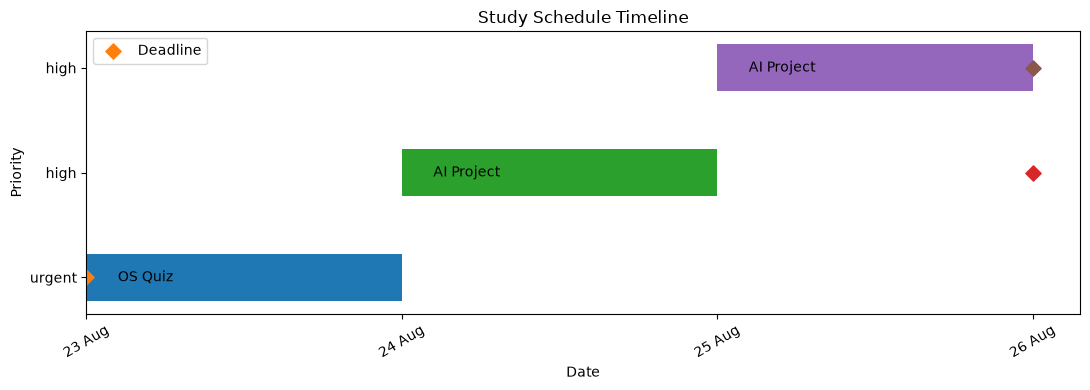

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

schedule_df = pd.DataFrame(schedule)

schedule_df["study_day"] = pd.to_datetime(schedule_df["study_day"])
schedule_df["deadline"] = pd.to_datetime(schedule_df["deadline"])

fig, ax = plt.subplots(figsize=(11, 4))

y_positions = range(len(schedule_df))

for i, row in schedule_df.iterrows():

    ax.barh(
        i,
        1,
        left=mdates.date2num(row["study_day"]),
        height=0.45
    )

    ax.text(
        mdates.date2num(row["study_day"]) + 0.1,
        i,
        row["task"],
        va="center",
        fontsize=10
    )

    ax.scatter(
        mdates.date2num(row["deadline"]),
        i,
        marker="D",
        s=60,
        label="Deadline" if i == 0 else ""
    )

ax.set_yticks(list(y_positions))
ax.set_yticklabels(schedule_df["priority"])

ax.set_title("Study Schedule Timeline")
ax.set_xlabel("Date")
ax.set_ylabel("Priority")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator())

plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
today_df = schedule_df[schedule_df["study_day"] == pd.Timestamp.today().normalize()]

print("🎯 TODAY'S FOCUS\n")

if today_df.empty:
    print("No study sessions scheduled for today.")
else:
    for _, row in today_df.iterrows():
        print(f"• {row['task']}")
        print(f"  Deadline: {row['deadline'].strftime('%d %b %Y')}")
        print(f"  Priority: {row['priority'].capitalize()}")
        print()

🎯 TODAY'S FOCUS

• OS Quiz
  Deadline: 23 Aug 2026
  Priority: Urgent



In [24]:
trace_df = pd.DataFrame(show_trace())

trace_df

,time,step,details
0,22:57:40,add_task,OS Quiz (urgent)
1,22:57:40,add_task,DSA Assignment (urgent)
2,22:57:40,add_task,AI Project (high)
3,22:58:35,build_schedule,3 sessions generated
4,23:00:02,add_task,Operating Systems Viva (urgent)
